# Пример работы со статистическими методами.
Компания предоставила три датасета с данными о пользователях сервиса, их поездках за один год, а также стоимости услуг в подписках. Необходимо проанализировать демографию пользователей и особенности использования самокатов, а также определить возможную выгоду от распространения платной подписки на самокаты.

# Описание данных

Таблица с пользователями `users_go.csv`

- `user_id` — уникальный идентификатор пользователя.

- `name` — имя пользователя.

- `age` — возраст.

- `city` — город.

- `subscription_type` — тип подписки: `free`, `ultra`.

Таблица с поездками `rides_go.csv`

- `user_id` — уникальный идентификатор пользователя.

- `distance` — расстояние в метрах, которое пользователь проехал в текущей сессии.

- `duration` — продолжительность сессии в минутах, то есть время с того момента, как пользователь нажал кнопку «Начать поездку», до того, как он нажал кнопку «Завершить поездку».

- `date` — дата совершения поездки.

Таблица с подписками `subscriptions_go.csv`

- `subscription_type` — тип подписки.

- `minute_price` — стоимость одной минуты поездки по этой подписке.

- `start_ride_price` — стоимость начала поездки.

- `subscription_fee` — стоимость ежемесячного платежа.

---
## Задание 1. Загрузка данных

### Задача 1.1 Импорт библиотеки pandas

In [1]:
import pandas as pd

### Задача 1.2 Чтение данных

- https://code.s3.yandex.net/datasets/users_go.csv
- https://code.s3.yandex.net/datasets/rides_go.csv
- https://code.s3.yandex.net/datasets/subscriptions_go.csv

In [2]:
df_users_go = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
df_rides_go = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
df_subscriptions_go = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

### Задача 1.3 Печать первых строк

In [3]:
df_users_go.head(5)

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
df_rides_go.head(5)

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [5]:
df_subscriptions_go.head(5)

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


### Задача 1.4 Подсчёт строк
Определим количество строк в каждом из трёх датафреймов. 

In [6]:
dug = len(df_users_go)
drg = len(df_rides_go)
dsg = len(df_subscriptions_go)

print(dug, drg, dsg)

1565 18068 2


---
## Задание 2. Знакомство с данными и их предварительная подготовка

### Задача 2.1 Определение типов данных

In [7]:
df_rides_go.dtypes

user_id       int64
distance    float64
duration    float64
date         object
dtype: object

### Задача 2.2 Преобразование форматов данных
Приведём столбец `date` в датафрейме `df_rides_go` к типу даты pandas, используя метод `pd.to_datetime()`.

In [8]:
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'])

### Задача 2.3 Создание столбца с месяцем
На основе столбца `date` создайм новый столбец `month`, содержащий номер месяца.

In [9]:
df_rides_go['month'] = df_rides_go['date'].dt.month

### Задача 2.4 Поиск дублей и пропусков

In [10]:
missing_values = df_users_go.isna().sum().sum()
duplicate_rows = df_users_go.duplicated().sum()
print(missing_values, duplicate_rows)

0 31


### Задача 2.5 Заполнение пропусков и удаление дублей

In [11]:
df_users_go = df_users_go.fillna(0).drop_duplicates()

df_rides_go = df_rides_go.fillna(0).drop_duplicates()

df_subscriptions_go = df_subscriptions_go.fillna(0).drop_duplicates()

### Задача 2.6 Округление длительности поездки
В датафрейме поездок `df_rides_go` округлим время поездки `duration` до целого числа стандартным методом `round()`. Затем приведём эту колонку к целочисленному типу `int`.

In [12]:
df_rides_go['duration'] = df_rides_go['duration'].round().astype(int)

---
## Задание 3. Исследовательский анализ данных (EDA)


### Задача 3.1 Импорт библиотеки matplotlib

In [13]:
import matplotlib.pyplot as plt

### Задача 3.2 Количество пользователей по городам.
Пользуясь данными из датафрейма `df_users_go`, изучим количество пользователей в каждом из городов. Создадим и выведим на экран объект `pd.Series`, названный `users_by_city_count`, с одной колонкой `count` — суммарным количеством пользователей в каждом городе `city`, отсортированным по убыванию.

In [14]:
users_by_city_count = df_users_go.groupby('city').size().sort_values(ascending=False)
users_by_city_count.index.name = None
users_by_city_count.name = 'city'

print(users_by_city_count)

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64


### Задача 3.3 Количество пользователей подписки
Создаим и выведим на экран серию `subscription_type_count` с количеством пользователей для каждого типа подписки `subscription_type`.

In [15]:
df = df_users_go.merge(df_subscriptions_go, left_on = 'subscription_type', right_on = 'subscription_type')
subscription_type_count = df['subscription_type'].value_counts()
print(subscription_type_count)

free     835
ultra    699
Name: subscription_type, dtype: int64


### Задача 3.4 Круговая диаграмма
Постройм круговую диаграмму, указав процент пользователей с `free` и `ultra` подпиской. 

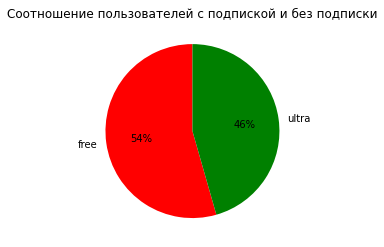

In [16]:
import matplotlib.pyplot as plt

# Объединяем данные
df = df_users_go.merge(df_subscriptions_go, left_on='subscription_type', right_on='subscription_type')

# Получаем количество пользователей по типам подписки
subscription_type_count = df['subscription_type'].value_counts()

# Строим круговую диаграмму с нужными параметрами
subscription_type_count.plot(kind='pie',
                            title='Соотношение пользователей с подпиской и без подписки',
                            autopct='%.0f%%',
                            ylabel='',
                            colors=['red', 'green'],  # green для подписчиков, red для free
                            startangle=90)  # поворот на 90 градусов для лучшего отображения

# Отображаем диаграмму
plt.show()

### Задача 3.5 Гистограмма возрастов
Построим гистограмму возрастов `age` пользователей самокатов.

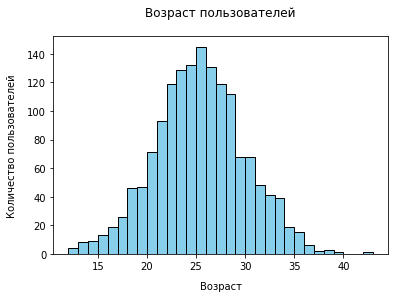

In [17]:
# Рассчитываем количество бинов
age_data = df_users_go['age']
n_bins = int(age_data.max() - age_data.min())

# Правильный вызов hist() - для самого столбца
age_data.hist(bins=n_bins, 
             color='skyblue',
             edgecolor='black',
             grid=False)

# Настройка оформления
plt.title('Возраст пользователей', pad=20)
plt.xlabel('Возраст', labelpad=10)
plt.ylabel('Количество пользователей', labelpad=10)

# Отображение
plt.show()

### Задача 3.6 Несовершеннолетние пользователи
Рассчитайте долю несовершеннолетних (возрастом менее 18 лет) пользователей самокатов.

In [18]:
# Рассчитываем количество пользователей младше 18 лет
under_18_count = df_users_go[df_users_go['age'] < 18].shape[0]

# Общее количество пользователей
total_users = df_users_go.shape[0]

# Вычисляем долю и округляем до целого числа
users_under_18_ratio = int(round((under_18_count / total_users) * 100))

print(f'Доля несовершеннолетних пользователей самокатов составляет {users_under_18_ratio}%.')

Доля несовершеннолетних пользователей самокатов составляет 5%.


### Задача 3.7 Характеристики длительности поездки

С помощью описательной статистики изучим длительность поездок:

1. Используя колонку `duration` из датафрейма `df_rides_go`.
2. Расчитаем среднее значение и стандартное отклонение длительности поездки.
3. Рассчитаем 25-й и 75-й процентили длительности поездки.


In [20]:
duration_mean = int(df_rides_go['duration'].mean().round())
duration_std = int(df_rides_go['duration'].std().round())

duration_pct25 = int(df_rides_go['duration'].quantile(0.25))
duration_pct75 = int(df_rides_go['duration'].quantile(0.75))

print(f'Средняя длительность поездки {duration_mean} минут со стандартным отклонением {duration_std}. Основная часть поездок занимает от {duration_pct25} до {duration_pct75} минут.')

Средняя длительность поездки 18 минут со стандартным отклонением 6. Основная часть поездок занимает от 14 до 22 минут.


---
## Задание 4. Объединение данных

### Задача 4.1 Объединение таблицы пользователей и поездок
Объединим датафреймы с информацией о пользователях `df_users_go` и поездках `df_rides_go`. Полученный датафрейм назовём `df`.

In [21]:
df = df_users_go.merge(df_rides_go, left_on='user_id', right_on='user_id')

### Задача 4.2 Присоединение информации о подписках
Присоединим к полученному датафрейму `df` информацию о подписках из `df_subscriptions_go`.


In [23]:
df = df.merge(df_subscriptions_go, left_on='subscription_type', right_on='subscription_type')

### Задача 4.3. Размеры объединённого датафрейма

In [26]:
# Выводим первые пять строк датафрейма
display(df.head())

# Выводим количество строк и столбцов в объединённом датафрейме
n_rows, n_cols = df.shape
print(f'В полученном датафрейме {n_rows} строк и {n_cols} столбцов.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


В полученном датафрейме 18068 строк и 12 столбцов.


### Задача 4.4 Отдельные датафреймы для пользователей с подпиской и без
Создадим два вспомогательных датафрейма на основе `df`: первый только для пользователей с подпиской `df_ultra` и второй только для пользователей без подписки `df_free`.

In [30]:
df_ultra = df[df['subscription_type']=='ultra']
df_free = df[df['subscription_type']=='free']

### Задача 4.5 Гистограмма длительности поездок для обоих групп
Построим гистограмму распределения длительности поездок `duration` для пользователей с подпиской и без.

Что нужно сделать:

1. Установим размер графика: 15 по горизонтали и 5 по вертикали.
2. Отобразим данные из столбца `duration` датафрейма `df_free` с помощью метода `hist()`.
3. Отобразим данные из столбца `duration` датафрейма `df_ultra` с помощью метода `hist()`.

Дополнительно рассчитаем среднюю длительность поездки для пользователей с подпиской и без.

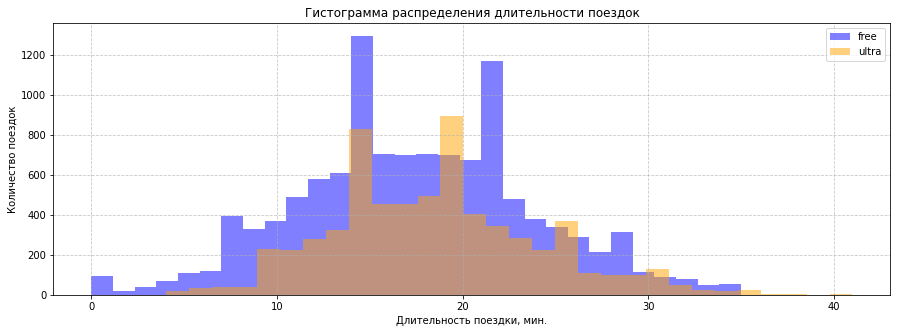

Средняя длительность поездки для пользователей без подписки 17 мин, а для пользователей с подпиской 19 мин


In [31]:
import matplotlib.pyplot as plt

# Гистограмма длительности поездки для пользователей с подпиской и без
plt.figure(figsize=(15, 5))

# Гистограмма для пользователей без подписки
df_free['duration'].hist(bins=30, alpha=0.5, label='free', color='blue')

# Гистограмма для пользователей с подпиской ultra
df_ultra['duration'].hist(bins=30, alpha=0.5, label='ultra', color='orange')

# Настройки графика
plt.xlabel('Длительность поездки, мин.')
plt.ylabel('Количество поездок')
plt.title('Гистограмма распределения длительности поездок')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Расчет и вывод на экран средней длительности поездки
mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())

print(f'Средняя длительность поездки для пользователей без подписки {mean_duration_free} мин, а для пользователей с подпиской {mean_duration_ultra} мин')

---
## Задание 5. Подсчёт выручки

### Задача 5.1 Данные сгруппированные по нужным колонкам
Сгруппируем данные по следующим столбцам: `user_id`, `name`, `subscription_type`, `month`.


In [33]:
df_gp = df.groupby(['user_id', 'name', 'subscription_type', 'month'], as_index=False)

### Задача 5.2 Подсчёт агрегированных метрик
Создаём новый датафрейм `df_agg`. В нём для каждой группы рассчитаем и добавим в датафрейм следующие агрегированные значения, используя метод `agg()`:
- `total_distance` — сумма значений в столбце `distance`.
- `total_duration` — сумма значений в столбце `duration`.
- `rides_count` — количество элементов в столбце `duration`.
- `subscription_type` — первое значение в группе для столбца `subscription_type`.
- `minute_price` — первое значение в группе для столбца `minute_price`.
- `start_ride_price` — первое значение в группе для столбца `start_ride_price`.
- `subscription_fee` — первое значение в группе для столбца `subscription_fee`.

In [37]:
df_agg = df_gp.agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration', 'sum'),
    rides_count=('duration', 'count'),
    subscription_type=('subscription_type', 'first'),
    minute_price=('minute_price', 'first'),
    start_ride_price=('start_ride_price', 'first'),
    subscription_fee=('subscription_fee', 'first')
)

### Задача 5.3 Функция для подсчёта выручки
Создадим функцию `calculate_monthly_revenue(row)` для расчёта месячной выручки по формуле:

`monthly_revenue` = `start_ride_price` * `rides_count` + `minute_price` * `total_duration` + `subscription_fee`

В качестве входных данных функция будет принимать одну строку `row` датафрейма. Вспомните, как в таком случае обращаться к каждой колонке.

Здесь:
- `start_ride_price * rides_count` — выручка от начала каждой поездки.
- `minute_price * total_duration` — выручка за время использования.
- `subscription_fee` — фиксированная выручка от подписок.

In [39]:
def calculate_monthly_revenue(row):
    """
    Рассчитывает месячную выручку по формуле:
    (start_ride_price * rides_count) + (minute_price * total_duration) + subscription_fee
    """
    monthly_revenue = (row['start_ride_price'] * row['rides_count'] + 
                      row['minute_price'] * row['total_duration'] + 
                      row['subscription_fee'])
    return monthly_revenue

### Задача 5.4 Создание столбца с месячной выручкой на пользователя
Создадим новый столбец с месячной выручкой на пользователя `monthly_revenue`. Для этого применим функцию `calculate_monthly_revenue(row)` к каждой строке агрегированного датафрейма `df_agg`.

In [41]:
df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue, axis=1)

### Задача 5.5 Поиск пользователя с максимальной выручкой

In [46]:
# Находим пользователя с максимальной суммарной выручкой
total_revenue = df_agg.groupby(['user_id', 'name'])['monthly_revenue'].sum()
max_user_id, max_user_name = total_revenue.idxmax()

# Получаем данные пользователя, сохраняя исходные индексы
user_data = df_agg[(df_agg['user_id'] == max_user_id) & 
                  (df_agg['name'] == max_user_name)]\
                  .sort_values('month')

# Выводим результат с индексами
print(user_data[['user_id', 'name', 'month', 'rides_count', 'monthly_revenue']])

      user_id       name  month  rides_count  monthly_revenue
8877     1236  Александр      1            2              228
8878     1236  Александр      2            3              614
8879     1236  Александр      3            5              762
8880     1236  Александр      4            1              202
8881     1236  Александр      5            3              574
8882     1236  Александр      6            1              282
8883     1236  Александр      7            1              290
8884     1236  Александр      8            2              452
8885     1236  Александр      9            1              122
8886     1236  Александр     10            3              430
8887     1236  Александр     11            3              494
8888     1236  Александр     12            2              476


---
## Задание 6. Проверка гипотез

### Задача 6.1 Импорт библиотеки SciPy

In [47]:
import scipy.stats as st

### Задача 6.2 Вспомогательная функция для интерпретации результатов
Напишим вспомогательную функцию `print_stattest_results(p_value, alpha)`, которая будет интерпретировать результаты статистического теста на основе p-value и заданного уровня значимости (α-уровня). Функция будет решать, следует ли принять альтернативную гипотезу или сохранить нулевую гипотезу.

У функции два параметра:
- `p_value` (тип `float`) — значение p-value, полученное в результате выполнения статистического теста.
- `alpha` (тип `float`, необязательный, по умолчанию `alpha = 0.05`) — уровень значимости статистического теста, который используется как порог для принятия решения об отклонении нулевой гипотезы.

In [51]:
def print_stattest_results(p_value, alpha=0.05):
    """
    Интерпретирует результаты статистического теста на основе p-value и уровня значимости alpha.
    
    Параметры:
        p_value (float): полученное значение p-value
        alpha (float): уровень значимости (по умолчанию 0.05)
    """
    if p_value < alpha:
        print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
    else:
        print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')

# Примеры вызова функции
print_stattest_results(p_value=0.0001)  # p-value < alpha
print_stattest_results(p_value=0.1)     # p-value > alpha

Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### Задача 6.3 Длительность для пользователей с подпиской и без

Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Сформулируем нулевую и альтернативную гипотезы:
- Нулевая гипотеза (Н0): Среднее время поездки у пользователей с подпиской и без подписки одинаковое.
- Альтернативная гипотеза (Н1): Среднее время поездки у пользователей с подпиской больше, чем у пользователей без подписки.

In [58]:
from scipy import stats as st

# Получаем данные о длительности поездок
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

# Проводим t-тест (односторонний, так как проверяем "больше")
test_results = st.ttest_ind(ultra_duration, free_duration, alternative='greater')

# Извлекаем p-value из результатов теста
p_value = test_results.pvalue

# Интерпретируем результаты
print_stattest_results(p_value)

# Считаем средние длительности
ultra_mean_duration = round(ultra_duration.mean(), 2)
free_mean_duration = round(free_duration.mean(), 2)

print(f'Средняя длительность поездки тарифа Ultra {ultra_mean_duration}')
print(f'Средняя длительность поездки тарифа Free {free_mean_duration}')

Полученное значение p_value=3.1600689435611813e-35 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя длительность поездки тарифа Ultra 18.55
Средняя длительность поездки тарифа Free 17.39


### Задача 6.4 Длительность поездки: больше или меньше критического значения

Проанализируем ещё одну гипотезу. Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, меньше 3130 метров?

Сформулируем нулевую и альтернативную гипотезы:

- Нулевая гипотеза (Н0): Средняя дистанция поездки у пользователей с подпиской равна 3130 м.

- Альтернативная гипотеза (Н1): Средняя дистанция поездки у пользователей с подпиской больше 3130 м.

In [62]:
null_hypothesis = 3130

# Получаем данные о дистанциях поездок пользователей с подпиской ultra
ultra_distance = df_ultra['distance']

# Проводим односторонний t-тест (проверяем "больше")
results = st.ttest_1samp(ultra_distance, null_hypothesis, alternative='greater')

# Для одностороннего теста делим p-value на 2
p_value = results.pvalue

# Интерпретируем результаты
print_stattest_results(p_value)

Полученное значение p_value=0.9195368847849785 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### Задача 6.5 Прибыль от пользователей с подпиской и без
Проверим гипотезу о том, что выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.

Сформулируем нулевую и альтернативную гипотезы:

- Нулевая гипотеза (Н0): Средняя месячная выручка у пользователей с подпиской и без подписки одинаковая.
- Альтернативная гипотеза (Н1): Средняя месячная выручка у пользователей с подпиской выше, чем у пользователей без подписки.

In [64]:
revenue_ultra = df_agg[df_agg['subscription_type'] == 'ultra']['monthly_revenue']
revenue_free = df_agg[df_agg['subscription_type'] == 'free']['monthly_revenue']

results = st.ttest_ind(revenue_ultra, revenue_free, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)

mean_revenue_ultra = round(revenue_ultra.mean())
mean_revenue_free = round(revenue_free.mean())

print(f'Средняя выручка подписчиков Ultra {mean_revenue_ultra} руб')
print(f'Средняя выручка подписчиков Free {mean_revenue_free} руб')

Полученное значение p_value=1.7274069878387966e-37 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя выручка подписчиков Ultra 359 руб
Средняя выручка подписчиков Free 322 руб


---
## Задание 7. Распределения

Имеется идея предлагать дополнительную скидку подписчикам, совершающим длительные поездки продолжительностью более 30 минут. Необходимо оценить долю таких поездок.

Учитывая, что у нас нет доступа ко всем данным о поездках, было решено смоделировать длительность поездки с помощью нормального распределения, используя в качестве параметров выборочное среднее и стандартное отклонение из доступных данных о поездках.

### Задача 7.1 Расчёт выборочного среднего и стандартного отклонения

1. Расчитаем среднюю длительность поездки и сохраним в переменную `mu`.
2. Вычислим стандартное отклонение длительности `duration` и сохраним в переменную `sigma`. Для вычисления стандартного отклонения применим метод `std()` к столбцу датасета.
3. Зададим значение переменной `target_time`, равное `30`. Эта переменная будет использоваться для последующего вычисления вероятности.

In [67]:
# Вычисляем среднее значение
mu = df_ultra['duration'].mean()

# Вычисляем стандартное отклонение
sigma = df_ultra['duration'].std()

# Задаём целевое время
target_time = 30

# Делаем вывод
print(f'Средняя длительность поездки {round(mu, 1)}, стандартное отклонение {round(sigma)}.')

Средняя длительность поездки 18.5, стандартное отклонение 6.


### Задача 7.2 Вычисление значения функции распределения в точке (CDF)
Если вычислить значение функции распределения в точке, это позволит узнать вероятность того, что случайная величина примет значение меньше заданного либо равное ему. Соответственно, если мы хотим ответить на вопрос о вероятности поездки более 30 минут, потребуется использовать CDF.

1. Используем функцию `norm()` из библиотеки SciPy для создания нормального распределения с параметрами `mu` и `sigma`.

2. Применим метод `cdf()` к целевому времени `target_time` для получения вероятности того, что случайная величина будет меньше этого значения или равна ему. Полученное значение сохраним в переменную `prob`.

In [70]:
# Вычисляем вероятность того, что случайная величина будет меньше указанного значения или равна ему

duration_norm_dist  = st.norm(loc=mu, scale=sigma) #st.
prob = round(1 - duration_norm_dist.cdf(target_time), 3) # Используем CDF для нахождения накопленной вероятности

print(f'Вероятность поездки более 30 минут {prob}')

Вероятность поездки более 30 минут 0.02


### Задача 7.3 Вероятность для интервала (CDF)
Известно, что процент пользователей, для которых будет показана скидка, недостаточно большой и вряд ли поможет в увеличении лояльности клиентов. Дополнительно есть задача проверить, какой процент пользователей совершает поездки в интервале от 20 до 30 минут. Возможно, именно для них стоит провести промоакцию?

Для этого:

1. Создадим переменные `low` и `high`, указывающие на начало и конец интересующего временного интервала. В этом случае они равны 20 и 30 минут.
2. Используем кумулятивную функцию распределения (CDF) для объекта `duration_norm_dist`, чтобы вычислить вероятность достижения верхней границы (`high`) и нижней границы (`low`).
3. Вычислим вероятность попадания в интервал и сохраним в переменную `prob_interval`.

In [72]:
# Определяем границы интервала
low = 20
high = 30

# Вычисляем вероятность попадания в интервал
prob_interval = round(duration_norm_dist.cdf(high) - duration_norm_dist.cdf(low), 3)

# Выводим результат
print(f'Вероятность того, что пользователь совершит поездку длительностью от {low} до {high} минут: {prob_interval}')

Вероятность того, что пользователь совершит поездку длительностью от 20 до 30 минут: 0.377


### Задача 7.4 Определение критической дистанции поездок (PPF)
Длительные поездки могут негативно сказываться на сроке службы самоката. В связи с этим принято решение установить критическую дистанцию, превышение которой будет сопровождаться дополнительной платой. Для этого необходимо определить расстояние, которое превышается только в 10% поездок.

Необходимо смоделировать распределение длительности поездок, предполагая, что оно подчиняется нормальному закону, и рассчитать критическую дистанцию, ниже которой находится 90% всех поездок.

Для этого:
1. Рассчитаем среднюю дистанцию поездки для всех пользователей из датафрейма `df` (с подпиской и без) и сохраним в переменную `mu`.
2. Вычислим стандартное отклонение дистанции поездки `distance` и сохраним в переменную `sigma`.
3. Зададим значение переменной `target_prob`, равное `0.90`. Эта переменная будет использоваться для последующего вычисления критической дистанции.
4. Создадим объект нормального распределения `distance_norm` с заданными значениями `mu` и `sigma`.
5. Применим к созданному нормальному распределению `distance_norm` метод `ppf()` и в качестве аргумента передадим целевую вероятность `target_prob`. Полученное значение сохраним в переменную `critical_distance`.



In [73]:
# Вычисляем среднее значение
mu = df['distance'].mean()

# Вычисляем стандартное отклонение
sigma = df['distance'].std()

# Вероятность, для которой хотим найти значение (90% случаев)
target_prob = 0.90

# Создаём объект нормального распределения
distance_norm = st.norm(loc=mu, scale=sigma)

# Рассчитываем критическую дистанцию для заданного процентиля поездок
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % поездок имеют дистанцию ниже критического значения {critical_distance:.2f} М.')

90.0 % поездок имеют дистанцию ниже критического значения 4501.94 М.
